# ATStereo — Results Analysis & Publication Suite
**Metrics:** Frame Registration RMSE (mm) & Workflow Time (seconds / minutes)  


In [30]:
import os
import glob
import shutil
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 12,
    'mathtext.fontset': 'dejavusans',
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.75,
    'grid.alpha': 0.5
})

def add_panel_label(ax, letter, x=-0.12, y=1.08):
    """Bold sans-serif panel label (e.g. 'A') at the top-left of an axis,
    matching Scientific Reports figure-lettering convention: same typeface
    and size as the rest of the figure's lettering, bold, upper-case."""
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=plt.rcParams['axes.titlesize'] + 2,
            fontweight='bold', va='top', ha='left')

op_colors = {
    'op1': '#1f77b4',
    'op2': '#ff7f0e',
    'op3': '#2ca02c',
    'op4': '#d62728',
    'op5': '#9467bd',
    'op6': '#8c564b',
    'op7': '#e377c2',
}

results_dir = os.path.dirname(os.path.abspath('__file__'))
print(f'Working directory: {results_dir}')


Working directory: /Users/abdelrahmantaha/Desktop/ATStereo/Results


## 1. Load and Clean Data
Auto-discovers all operator files and validates data integrity.

In [31]:
rmse_files = sorted(glob.glob(os.path.join(results_dir, 'ATStereo_Phase1_RMSE_op*.csv')))
time_files = sorted(glob.glob(os.path.join(results_dir, 'ATStereo_WorkflowTime_op*.csv')))

print(f'Found {len(rmse_files)} RMSE files: {[os.path.basename(f) for f in rmse_files]}')
print(f'Found {len(time_files)} Time files: {[os.path.basename(f) for f in time_files]}')

rmse_dfs = []
for f in rmse_files:
    op_name = os.path.basename(f).replace('ATStereo_Phase1_RMSE_', '').replace('.csv', '')
    df = pd.read_csv(f)
    df['Operator'] = op_name
    df['Trial'] = range(1, len(df) + 1)
    rmse_dfs.append(df)

df_rmse = pd.concat(rmse_dfs, ignore_index=True) if rmse_dfs else pd.DataFrame()

time_dfs = []
for f in time_files:
    op_name = os.path.basename(f).replace('ATStereo_WorkflowTime_', '').replace('.csv', '')
    df = pd.read_csv(f)
    df['Operator'] = op_name
    df['Trial'] = range(1, len(df) + 1)
    df['Total_Time_Minutes'] = df['Total_Time_Seconds'] / 60.0
    time_dfs.append(df)

df_time = pd.concat(time_dfs, ignore_index=True) if time_dfs else pd.DataFrame()

print(f'Total RMSE records: {len(df_rmse)}')
print(f'Total Workflow Time records: {len(df_time)}')


Found 5 RMSE files: ['ATStereo_Phase1_RMSE_op1.csv', 'ATStereo_Phase1_RMSE_op2.csv', 'ATStereo_Phase1_RMSE_op3.csv', 'ATStereo_Phase1_RMSE_op4.csv', 'ATStereo_Phase1_RMSE_op5.csv']
Found 5 Time files: ['ATStereo_WorkflowTime_op1.csv', 'ATStereo_WorkflowTime_op2.csv', 'ATStereo_WorkflowTime_op3.csv', 'ATStereo_WorkflowTime_op4.csv', 'ATStereo_WorkflowTime_op5.csv']
Total RMSE records: 156
Total Workflow Time records: 108


## 2. Normality Testing (Shapiro–Wilk Test)

In [32]:
norm_rows = []
for op in sorted(df_rmse['Operator'].unique()):
    v = df_rmse[df_rmse['Operator'] == op]['RMSE']
    w, p = stats.shapiro(v)
    norm_rows.append({'Metric': 'RMSE (mm)', 'Operator': op, 'N': len(v), 'W': round(w,4), 'p-value': f'{p:.4f}', 'Normal': 'Yes' if p>=0.05 else 'No'})

w_all, p_all = stats.shapiro(df_rmse['RMSE'])
norm_rows.append({'Metric': 'RMSE (Pooled)', 'Operator': 'All', 'N': len(df_rmse), 'W': round(w_all,4), 'p-value': f'{p_all:.4f}', 'Normal': 'Yes' if p_all>=0.05 else 'No'})

for op in sorted(df_time['Operator'].unique()):
    v = df_time[df_time['Operator'] == op]['Total_Time_Seconds']
    w, p = stats.shapiro(v)
    norm_rows.append({'Metric': 'Time (s)', 'Operator': op, 'N': len(v), 'W': round(w,4), 'p-value': f'{p:.4f}', 'Normal': 'Yes' if p>=0.05 else 'No'})

w_t_all, p_t_all = stats.shapiro(df_time['Total_Time_Seconds'])
norm_rows.append({'Metric': 'Time (Pooled)', 'Operator': 'All', 'N': len(df_time), 'W': round(w_t_all,4), 'p-value': f'{p_t_all:.4f}', 'Normal': 'Yes' if p_t_all>=0.05 else 'No'})

df_norm = pd.DataFrame(norm_rows)
display(df_norm)

,Metric,Operator,N,W,p-value,Normal
0,RMSE (mm),op1,69,0.9734,0.1471,Yes
1,RMSE (mm),op2,25,0.9569,0.3561,Yes
2,RMSE (mm),op3,22,0.9651,0.5996,Yes
3,RMSE (mm),op4,20,0.9188,0.0941,Yes
4,RMSE (mm),op5,20,0.8617,0.0084,No
5,RMSE (Pooled),All,156,0.9213,0.0000,No
6,Time (s),op1,35,0.9637,0.2940,Yes
7,Time (s),op2,11,0.7144,0.0007,No
8,Time (s),op3,22,0.9881,0.9923,Yes
9,Time (s),op4,20,0.7716,0.0003,No


## 3. Summary Statistics (Per-Operator & Aggregate)

In [33]:
operators = sorted(df_rmse['Operator'].unique())
operators_t = sorted(df_time['Operator'].unique())

# RMSE Table
rmse_stats = []
for op in operators:
    v = df_rmse[df_rmse['Operator'] == op]['RMSE']
    ci = stats.t.interval(0.95, len(v)-1, loc=v.mean(), scale=v.sem()) if len(v)>1 else (v.mean(), v.mean())
    q1, med, q3 = v.quantile([0.25, 0.5, 0.75])
    rmse_stats.append({
        'Operator': op, 'N': len(v), 'Mean': v.mean(), 'SD': v.std(),
        '95% CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]',
        'Median': med, 'IQR': q3 - q1, 'Min': v.min(), 'Max': v.max()
    })
df_rmse_stats = pd.DataFrame(rmse_stats)

grand_rmse_mean = df_rmse_stats['Mean'].mean()
grand_rmse_sd = df_rmse_stats['Mean'].std()
pooled_rmse_mean = df_rmse['RMSE'].mean()
pooled_rmse_sd = df_rmse['RMSE'].std()

print('=== RMSE Summary (mm) ===')
display(df_rmse_stats.round(3))
print(f'Grand Mean: {grand_rmse_mean:.2f} ± {grand_rmse_sd:.2f} mm | Pooled: {pooled_rmse_mean:.2f} ± {pooled_rmse_sd:.2f} mm')

# Time Table
time_stats = []
for op in operators_t:
    v_s = df_time[df_time['Operator'] == op]['Total_Time_Seconds']
    v_m = df_time[df_time['Operator'] == op]['Total_Time_Minutes']
    ci_s = stats.t.interval(0.95, len(v_s)-1, loc=v_s.mean(), scale=v_s.sem()) if len(v_s)>1 else (v_s.mean(), v_s.mean())
    q1_s, med_s, q3_s = v_s.quantile([0.25, 0.5, 0.75])
    time_stats.append({
        'Operator': op, 'N': len(v_s), 'Mean_s': v_s.mean(), 'SD_s': v_s.std(),
        'Mean_min': v_m.mean(), 'SD_min': v_m.std(),
        '95% CI (s)': f'[{ci_s[0]:.1f}, {ci_s[1]:.1f}]',
        'Median_s': med_s, 'IQR_s': q3_s - q1_s,
        'Min_s': v_s.min(), 'Max_s': v_s.max()
    })
df_time_stats = pd.DataFrame(time_stats)

grand_time_mean_s = df_time_stats['Mean_s'].mean()
grand_time_sd_s = df_time_stats['Mean_s'].std()
grand_time_mean_min = grand_time_mean_s / 60.0
grand_time_sd_min = grand_time_sd_s / 60.0
pooled_time_mean_min = df_time['Total_Time_Minutes'].mean()
pooled_time_sd_min = df_time['Total_Time_Minutes'].std()

print('\n=== Workflow Time Summary ===')
display(df_time_stats.round(2))
print(f'Grand Mean: {grand_time_mean_s:.1f} ± {grand_time_sd_s:.1f} s ({grand_time_mean_min:.2f} ± {grand_time_sd_min:.2f} min)')
print(f"Pooled time is {pooled_time_mean_min} ± {pooled_time_sd_min}")


=== RMSE Summary (mm) ===


,Operator,N,Mean,SD,95% CI,Median,IQR,Min,Max
0,op1,69,0.405,0.082,"[0.38, 0.42]",0.40,0.120,0.24,0.58
1,op2,25,0.603,0.201,"[0.52, 0.69]",0.63,0.330,0.26,0.94
2,op3,22,0.335,0.123,"[0.28, 0.39]",0.33,0.152,0.12,0.63
3,op4,20,0.310,0.097,"[0.26, 0.36]",0.29,0.105,0.18,0.58
4,op5,20,0.269,0.086,"[0.23, 0.31]",0.25,0.095,0.16,0.54


Grand Mean: 0.38 ± 0.13 mm | Pooled: 0.40 ± 0.15 mm

=== Workflow Time Summary ===


,Operator,N,Mean_s,SD_s,Mean_min,SD_min,95% CI (s),Median_s,IQR_s,Min_s,Max_s
0,op1,35,84.62,12.45,1.41,0.21,"[80.3, 88.9]",85.70,20.65,63.3,111.3
1,op2,11,75.75,23.33,1.26,0.39,"[60.1, 91.4]",64.60,15.40,55.4,138.8
2,op3,22,124.49,16.26,2.07,0.27,"[117.3, 131.7]",126.40,20.15,91.7,161.6
3,op4,20,119.49,29.91,1.99,0.50,"[105.5, 133.5]",110.70,18.52,85.5,212.6
4,op5,20,153.75,37.81,2.56,0.63,"[136.1, 171.4]",146.35,37.25,109.0,269.5


Grand Mean: 111.6 ± 31.7 s (1.86 ± 0.53 min)
Pooled time is 1.8516358024691357 ± 0.6038411135552126


## 4. Hypothesis Testing (Kruskal–Wallis)

In [34]:
h_rmse, p_rmse = stats.kruskal(*[df_rmse[df_rmse['Operator']==op]['RMSE'].values for op in operators])
h_time, p_time = stats.kruskal(*[df_time[df_time['Operator']==op]['Total_Time_Seconds'].values for op in operators_t])

print(f'Kruskal-Wallis RMSE: H = {h_rmse:.2f}, p = {p_rmse:.4e}')
print(f'Kruskal-Wallis Time: H = {h_time:.2f}, p = {p_time:.4e}')

Kruskal-Wallis RMSE: H = 60.80, p = 1.9717e-12
Kruskal-Wallis Time: H = 74.09, p = 3.1056e-15


## 5. Comparison with BrainStereo Benchmark

In [35]:
brainstereo_time_mean = 5.54
speedup = brainstereo_time_mean / grand_time_mean_min

comp_df = pd.DataFrame([
    {'Metric': 'RMSE (mean ± SD, mm)', 'ATStereo': f'{grand_rmse_mean:.2f} ± {grand_rmse_sd:.2f}', 'BrainStereo': '0.56 ± 0.23'},
    {'Metric': 'RMSE Range (mm)', 'ATStereo': f'{df_rmse["RMSE"].min():.2f}–{df_rmse["RMSE"].max():.2f}', 'BrainStereo': '0.05–1.14'},
    {'Metric': 'Workflow Time (mean ± SD, min)', 'ATStereo': f'{grand_time_mean_min:.2f} ± {grand_time_sd_min:.2f}', 'BrainStereo': '5.54 ± 1.16'},
    {'Metric': 'Speedup', 'ATStereo': f'{speedup:.1f}× faster', 'BrainStereo': '1.0×'}
])
display(comp_df)


,Metric,ATStereo,BrainStereo
0,"RMSE (mean ± SD, mm)",0.38 ± 0.13,0.56 ± 0.23
1,RMSE Range (mm),0.12–0.94,0.05–1.14
2,"Workflow Time (mean ± SD, min)",1.86 ± 0.53,5.54 ± 1.16
3,Speedup,3.0× faster,1.0×


## 6. Publication Figures (Figures 3, 4, 5, 6)

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/var/folders/yf/sjq94jrj1r78_z5fc3l377gw0000gn/T/ipykernel_4915/366048707.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(x_fit, stats.norm.pdf(x_fit, mu, std), 'k-', linewidth=1.5, label=f'Normal Fit ($\mu={mu:.2f}$)')
/var/folders/yf/sjq94jrj1r78_z5fc3l377gw0000gn/T/ipykernel_4915/366048707.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


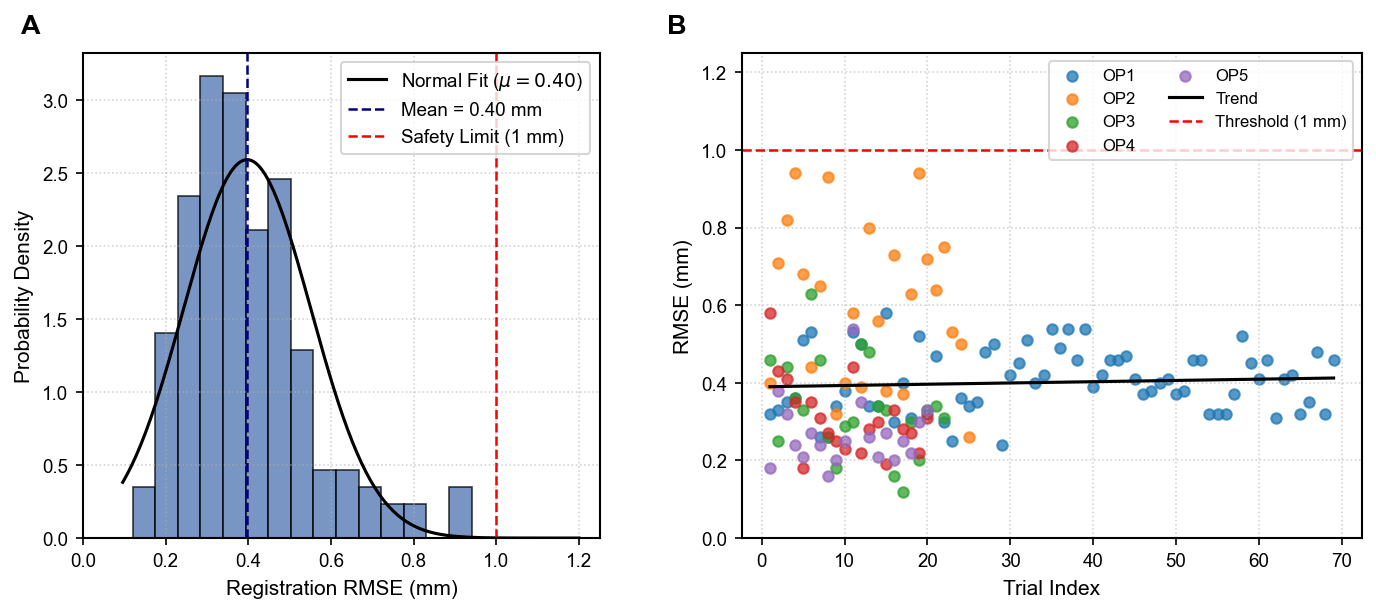

/var/folders/yf/sjq94jrj1r78_z5fc3l377gw0000gn/T/ipykernel_4915/366048707.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


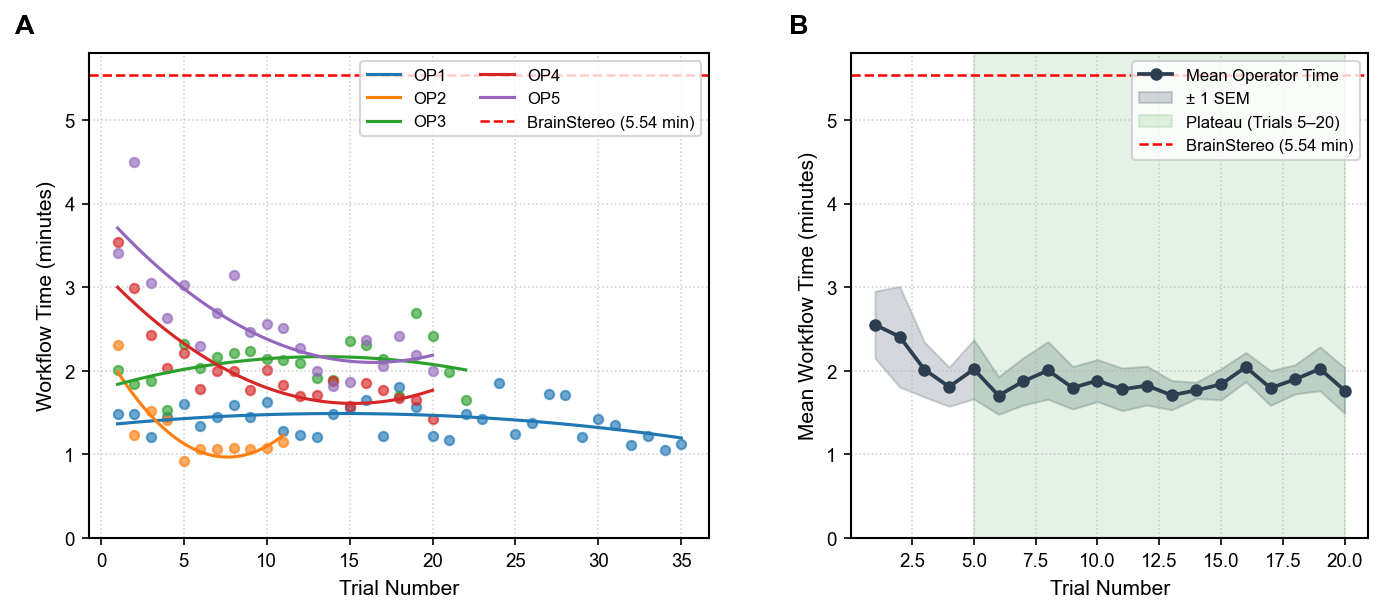

/var/folders/yf/sjq94jrj1r78_z5fc3l377gw0000gn/T/ipykernel_4915/366048707.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


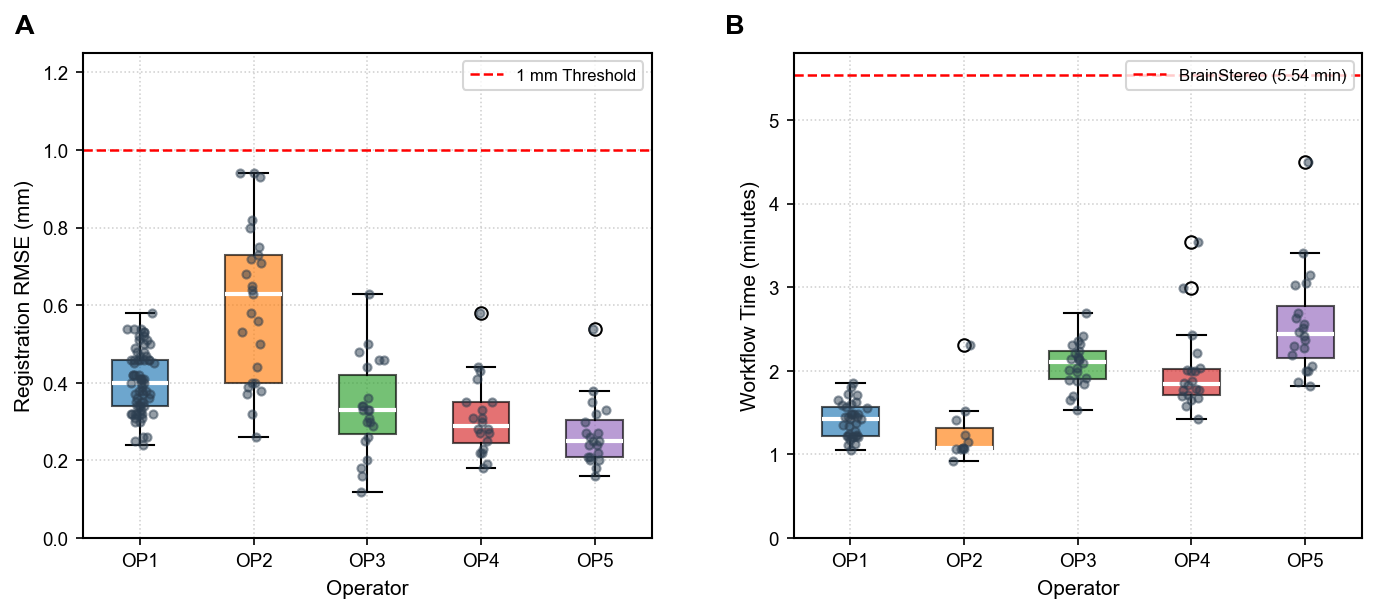

/var/folders/yf/sjq94jrj1r78_z5fc3l377gw0000gn/T/ipykernel_4915/366048707.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


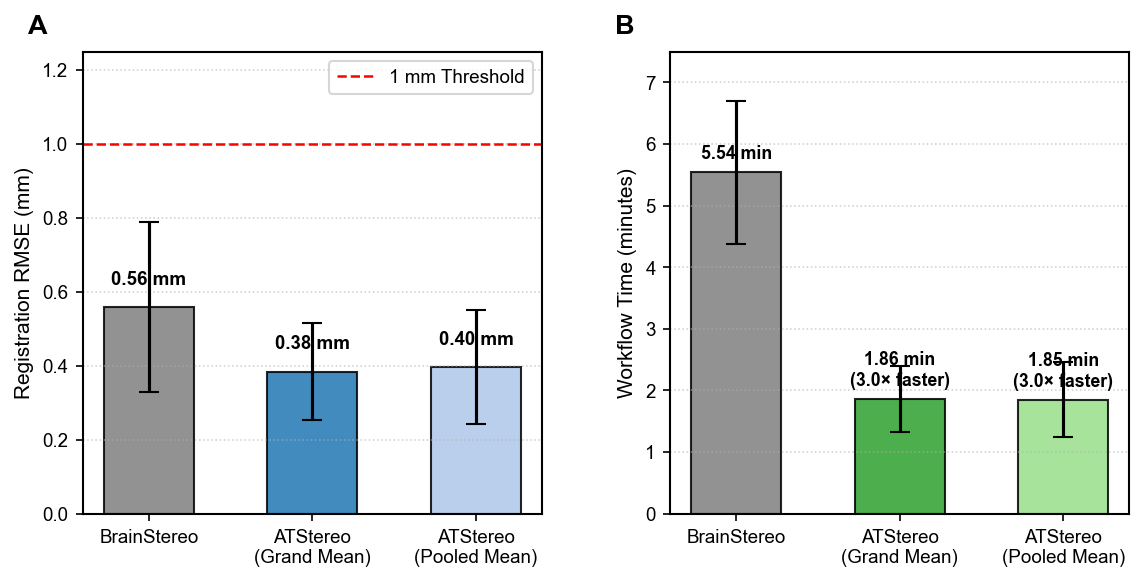

In [ ]:
# --- Figure 3: RMSE Distribution ---
fig = plt.figure(figsize=(11, 4.2))
gs = GridSpec(1, 2, width_ratios=[1, 1.2], wspace=0.25)

ax1 = fig.add_subplot(gs[0])
add_panel_label(ax1, 'A')
ax1.hist(df_rmse['RMSE'], bins=15, density=True, color='#4C72B0', alpha=0.75, edgecolor='black', linewidth=0.8)
mu, std = stats.norm.fit(df_rmse['RMSE'])
x_fit = np.linspace(df_rmse['RMSE'].min() * 0.8, 1.2, 200)
ax1.plot(x_fit, stats.norm.pdf(x_fit, mu, std), 'k-', linewidth=1.5, label=f'Normal Fit ($\mu={mu:.2f}$)')
ax1.axvline(mu, color='navy', linestyle='--', linewidth=1.2, label=f'Mean = {mu:.2f} mm')
ax1.axvline(1, color='red', linestyle='--', linewidth=1.2, label='Safety Limit (1 mm)')
ax1.set_xlabel('Registration RMSE (mm)')
ax1.set_ylabel('Probability Density')
ax1.legend(loc='upper right', frameon=True)
ax1.set_xlim(0, 1.25)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = fig.add_subplot(gs[1])
add_panel_label(ax2, 'B')
for op in operators:
    op_d = df_rmse[df_rmse['Operator'] == op]
    ax2.scatter(op_d['Trial'], op_d['RMSE'], color=op_colors.get(op, '#333'), alpha=0.75, s=25, label=f'{op.upper()}')
x_all = df_rmse['Trial'].values
y_all = df_rmse['RMSE'].values
z = np.polyfit(x_all, y_all, 1)
ax2.plot(np.linspace(1, max(x_all), 100), np.poly1d(z)(np.linspace(1, max(x_all), 100)), color='black', linestyle='-', linewidth=1.5, label='Trend')
ax2.axhline(1, color='red', linestyle='--', linewidth=1.2, label='Threshold (1 mm)')
ax2.set_xlabel('Trial Index')
ax2.set_ylabel('RMSE (mm)')
ax2.legend(loc='upper right', ncol=2, frameon=True, fontsize=8)
ax2.set_ylim(0, 1.25)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- Figure 4: Learning Curve ---
fig = plt.figure(figsize=(11, 4.2))
gs = GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.25)

ax1 = fig.add_subplot(gs[0])
add_panel_label(ax1, 'A')
for op in operators_t:
    op_d = df_time[df_time['Operator'] == op].sort_values('Trial')
    x = op_d['Trial'].values
    y = op_d['Total_Time_Minutes'].values
    c = op_colors.get(op, '#333')
    ax1.scatter(x, y, color=c, alpha=0.65, s=20)
    if len(x) >= 3:
        p2 = np.polyfit(x, y, 2)
        xg = np.linspace(x.min(), x.max(), 50)
        ax1.plot(xg, np.poly1d(p2)(xg), color=c, linewidth=1.5, label=f'{op.upper()}')
ax1.axhline(5.54, color='red', linestyle='--', linewidth=1.2, label='BrainStereo (5.54 min)')
ax1.set_xlabel('Trial Number')
ax1.set_ylabel('Workflow Time (minutes)')
ax1.legend(loc='upper right', ncol=2, frameon=True, fontsize=8)
ax1.set_ylim(0, 5.8)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = fig.add_subplot(gs[1])
add_panel_label(ax2, 'B')
trials_c = np.arange(1, 21)
m_by_t = [df_time[df_time['Trial'] == t]['Total_Time_Minutes'].mean() for t in trials_c]
s_by_t = [df_time[df_time['Trial'] == t]['Total_Time_Minutes'].sem() for t in trials_c]
mask = ~np.isnan(m_by_t)
ax2.plot(trials_c[mask], np.array(m_by_t)[mask], 'o-', color='#2c3e50', linewidth=1.8, markersize=5, label='Mean Operator Time')
ax2.fill_between(trials_c[mask], np.array(m_by_t)[mask] - np.array(s_by_t)[mask], np.array(m_by_t)[mask] + np.array(s_by_t)[mask], color='#2c3e50', alpha=0.2, label='± 1 SEM')
ax2.axvspan(5, 20, color='green', alpha=0.1, label='Plateau (Trials 5–20)')
ax2.axhline(5.54, color='red', linestyle='--', linewidth=1.2, label='BrainStereo (5.54 min)')
ax2.set_xlabel('Trial Number')
ax2.set_ylabel('Mean Workflow Time (minutes)')
ax2.legend(loc='upper right', frameon=True, fontsize=8)
ax2.set_ylim(0, 5.8)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Figure 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'wspace': 0.25})
add_panel_label(ax1, 'A')
add_panel_label(ax2, 'B')

rmse_d = [df_rmse[df_rmse['Operator'] == op]['RMSE'].values for op in operators]
bp1 = ax1.boxplot(rmse_d, tick_labels=[op.upper() for op in operators], patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, op in zip(bp1['boxes'], operators):
    patch.set_facecolor(op_colors.get(op, '#4C72B0'))
    patch.set_alpha(0.65)
for i, d in enumerate(rmse_d):
    ax1.scatter(np.random.normal(i + 1, 0.05, size=len(d)), d, color='#2c3e50', alpha=0.5, s=15, zorder=3)
ax1.axhline(1, color='red', linestyle='--', linewidth=1.2, label='1 mm Threshold')
ax1.set_xlabel('Operator')
ax1.set_ylabel('Registration RMSE (mm)')
ax1.set_ylim(0, 1.25)
ax1.legend(loc='upper right', frameon=True, fontsize=8)
ax1.grid(True, linestyle=':', alpha=0.6)

time_d = [df_time[df_time['Operator'] == op]['Total_Time_Minutes'].values for op in operators_t]
bp2 = ax2.boxplot(time_d, tick_labels=[op.upper() for op in operators_t], patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, op in zip(bp2['boxes'], operators_t):
    patch.set_facecolor(op_colors.get(op, '#55A868'))
    patch.set_alpha(0.65)
for i, d in enumerate(time_d):
    ax2.scatter(np.random.normal(i + 1, 0.05, size=len(d)), d, color='#2c3e50', alpha=0.5, s=15, zorder=3)
ax2.axhline(5.54, color='red', linestyle='--', linewidth=1.2, label='BrainStereo (5.54 min)')
ax2.set_xlabel('Operator')
ax2.set_ylabel('Workflow Time (minutes)')
ax2.set_ylim(0, 5.8)
ax2.legend(loc='upper right', frameon=True, fontsize=8)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- Figure 6: Benchmark Comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.0), gridspec_kw={'wspace': 0.28})
add_panel_label(ax1, 'A')
add_panel_label(ax2, 'B')
labels = ['BrainStereo', 'ATStereo\n(Grand Mean)', 'ATStereo\n(Pooled Mean)']

bars1 = ax1.bar(labels, [0.56, grand_rmse_mean, pooled_rmse_mean], yerr=[0.23, grand_rmse_sd, pooled_rmse_sd], capsize=5, color=['#7f7f7f', '#1f77b4', '#aec7e8'], alpha=0.85, edgecolor='black', width=0.55)
ax1.axhline(1, color='red', linestyle='--', linewidth=1.2, label='1 mm Threshold')
ax1.set_ylabel('Registration RMSE (mm)')
ax1.set_ylim(0, 1.25)
ax1.grid(True, linestyle=':', alpha=0.6, axis='y')
ax1.legend(loc='upper right', frameon=True)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05, f'{bar.get_height():.2f} mm', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = ax2.bar(labels, [5.54, grand_time_mean_min, pooled_time_mean_min], yerr=[1.16, grand_time_sd_min, pooled_time_sd_min], capsize=5, color=['#7f7f7f', '#2ca02c', '#98df8a'], alpha=0.85, edgecolor='black', width=0.55)
ax2.set_ylabel('Workflow Time (minutes)')
ax2.set_ylim(0, 7.5)
ax2.grid(True, linestyle=':', alpha=0.6, axis='y')
for bar, sp in zip(bars2, [1.0, speedup, brainstereo_time_mean / pooled_time_mean_min]):
    h = bar.get_height()
    ann = f'{h:.2f} min' if sp == 1.0 else f'{h:.2f} min\n({sp:.1f}× faster)'
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.15, ann, ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()
